<a href="https://colab.research.google.com/github/LesegoMasilela/financial-transaction-analysis/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn

**LOAD DATA**


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/train.csv")

# View first rows
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

**INSPECTION**

In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

**DATA CLEANING**

In [7]:
# Drop duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

print(f"DataFrame shape after dropping duplicates and NaNs: {df.shape}")

DataFrame shape after dropping duplicates and NaNs: (9789, 18)


**EXPLORATORY DATA ANALYSIS(EDA)**


In [8]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 2252607.4127


**SALES BY CATEGORY**

In [9]:
sales_by_category = df.groupby("Category")["Sales"].sum()
print(sales_by_category)

Category
Furniture          723538.4757
Office Supplies    703212.8240
Technology         825856.1130
Name: Sales, dtype: float64


**SALES OVER TIME**

<Axes: xlabel='Order Date'>

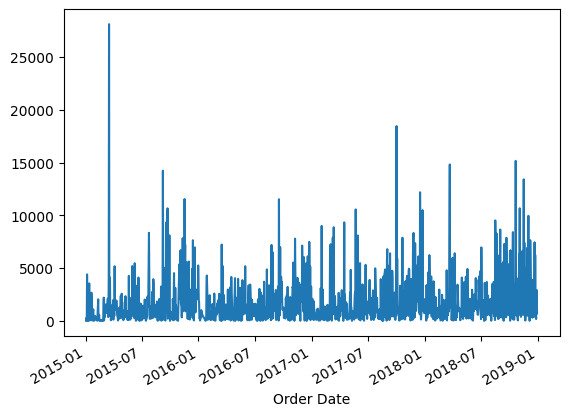

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

sales_over_time = df.groupby("Order Date")["Sales"].sum()

sales_over_time.plot()

**VISUALIZATION**

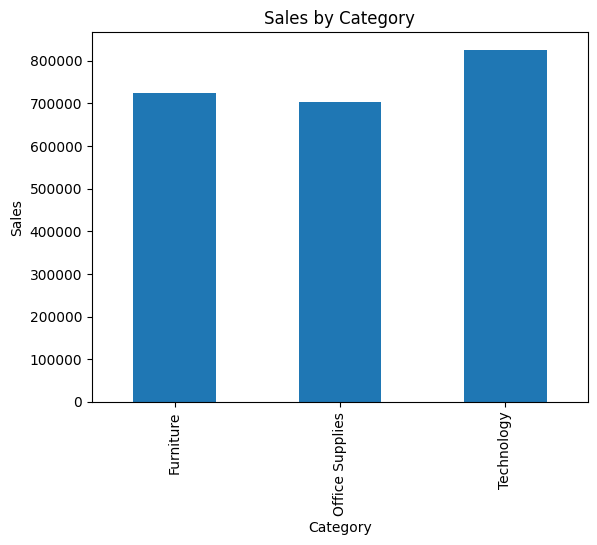

In [12]:
import matplotlib.pyplot as plt

sales_by_category.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

**KEY INSIGHT**

### Data Overview and Cleaning

- The initial dataset contained 9800 rows. After dropping duplicate entries and rows with missing values (specifically in 'Postal Code'), the dataset was reduced to 9789 entries.

### Sales Performance

- The **total sales** across all products amounted to **2,252,607.41**.
- Sales are distributed across three main categories, with **Technology** being the highest performing category:
    - **Technology**: 825,856.11
    - **Furniture**: 723,538.48
    - **Office Supplies**: 703,212.82

### Sales Trends

- The `sales_over_time` plot indicates the overall trend of sales over the recorded period, allowing for visual identification of peaks and troughs.

These insights demonstrate how data analysis can support strategic decision-making in areas such as product focus, regional targeting, and demand forecasting.